# Vanishing & Exploding Gradients — a visual explainer

Companion to the ResNet paper (He et al., 2015). That paper opens by naming
*vanishing/exploding gradients* as the classic obstacle to deep networks — one
that was **already largely solved** by good initialization + normalization,
which is why ResNet had to go after a *different* problem (degradation).

This notebook builds the intuition from scratch with `numpy` + `matplotlib`:

1. **Why gradients are a product** — and why products explode or vanish.
2. **A real deep network** — watch the gradient die as it flows backward.
3. **Initialization to the rescue** — the fix the paper refers to.
4. **The ResNet trick** — how a skip connection rescues gradient flow.

Everything is self-contained — run top to bottom, then tweak the numbers.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Why a gradient is a *product*

Backpropagation uses the **chain rule**. To get the learning signal (gradient)
at an early layer, you multiply one factor per layer the signal passes through
on its way back:

$$\text{gradient}_{\text{early}} \;\approx\; r_1 \cdot r_2 \cdot r_3 \cdots r_L$$

Multiplying many numbers is unstable:

- every factor a bit **< 1**  → product shrinks to ~0  → **vanishing**
- every factor a bit **> 1**  → product blows up  → **exploding**
- factors right around **1**  → signal survives  → **stable** (the goal)

Let's just multiply a constant factor `r`, `L` times, and watch.

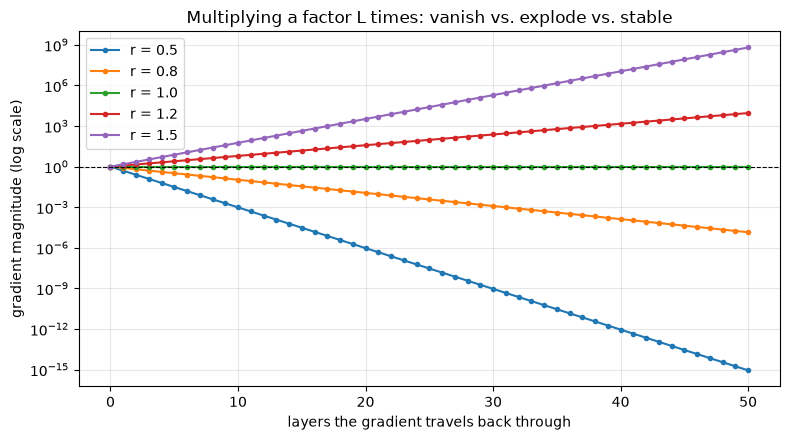

r=0.5:  after 50 layers, gradient x 8.882e-16
r=0.8:  after 50 layers, gradient x 1.427e-05
r=1.0:  after 50 layers, gradient x 1.000e+00
r=1.2:  after 50 layers, gradient x 9.100e+03
r=1.5:  after 50 layers, gradient x 6.376e+08


In [2]:
depth = np.arange(0, 51)          # up to 50 layers deep
factors = [0.5, 0.8, 1.0, 1.2, 1.5]

plt.figure()
for r in factors:
    grad = r ** depth             # product of `r`, `depth` times
    plt.plot(depth, grad, marker="o", ms=3, label=f"r = {r}")

plt.yscale("log")                 # note the LOG axis
plt.axhline(1.0, color="k", lw=0.8, ls="--")
plt.xlabel("layers the gradient travels back through")
plt.ylabel("gradient magnitude (log scale)")
plt.title("Multiplying a factor L times: vanish vs. explode vs. stable")
plt.legend()
plt.tight_layout(); plt.show()

for r in factors:
    print(f"r={r}:  after 50 layers, gradient x {r**50:.3e}")

**Read the plot.** The y-axis is a *log* scale, so straight lines are
exponential. `r = 0.5` plunges to ~1e-15 (vanished — no learning reaches the
early layers). `r = 1.5` rockets to ~1e+8 (exploded — updates go wild, values
overflow). Only `r = 1.0` stays flat. And "a bit off from 1" is enough: `r = 0.8`
still dies. **Deeper = more factors = worse.** This is the whole problem in one picture.

## 2. A real deep network

Constant `r` was a cartoon. In a real net the factor at each layer is roughly
*(the weight matrix) × (the activation's slope)*. Let's build an `L`-layer
network, run one forward + backward pass by hand, and record the gradient
magnitude at **each** layer.

We'll use `tanh` (a classic activation). Its slope is at most 1 and usually
less, so each layer tends to multiply by something **< 1** → expect vanishing.

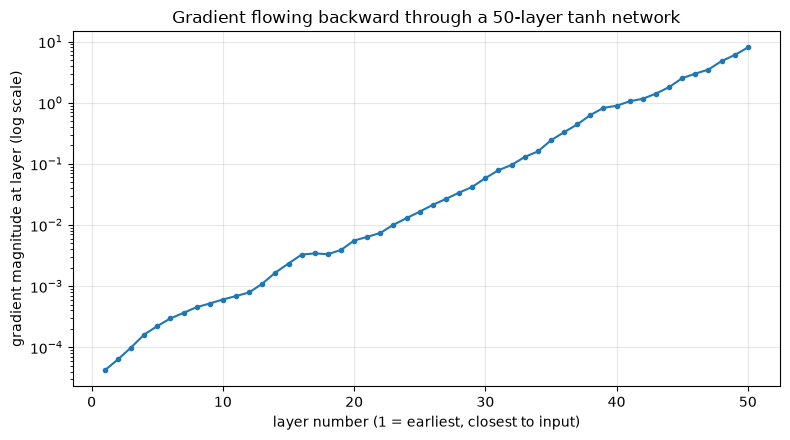

gradient at last layer : 8.000e+00
gradient at first layer: 4.200e-05
shrunk by a factor of  : 1.9e+05


In [3]:
def make_net(L, width=64, w_std=0.1, seed=0):
    rng = np.random.default_rng(seed)
    return [rng.normal(0, w_std, size=(width, width)) for _ in range(L)]

def forward_backward(weights):
    # one forward + backward pass; returns per-layer gradient norm
    width = weights[0].shape[0]
    a = np.random.default_rng(1).normal(0, 1, size=(width, 1))   # input
    cache = []                                # remember (a_prev, z) per layer
    for W in weights:
        z = W @ a
        cache.append((a, z))
        a = np.tanh(z)                        # activation
    # pretend the loss gradient at the output is all ones, then backprop
    da = np.ones_like(a)
    grad_norms = []
    for W, (a_prev, z) in zip(reversed(weights), reversed(cache)):
        dz = da * (1 - np.tanh(z) ** 2)       # tanh'(z)
        grad_norms.append(np.linalg.norm(dz)) # learning signal at this layer
        da = W.T @ dz                         # push gradient to previous layer
    return np.array(grad_norms[::-1])         # index 0 = first (earliest) layer

L = 50
grads = forward_backward(make_net(L, w_std=0.1))

plt.figure()
plt.plot(range(1, L + 1), grads, marker="o", ms=3)
plt.yscale("log")
plt.xlabel("layer number (1 = earliest, closest to input)")
plt.ylabel("gradient magnitude at layer (log scale)")
plt.title("Gradient flowing backward through a 50-layer tanh network")
plt.tight_layout(); plt.show()

print(f"gradient at last layer : {grads[-1]:.3e}")
print(f"gradient at first layer: {grads[0]:.3e}")
print(f"shrunk by a factor of  : {grads[-1] / grads[0]:.1e}")

The signal is strong at the output (right) and **decays exponentially** as it
travels back toward the input (left). The early layers — the ones that learn
basic features like edges — receive an almost-zero gradient, so they barely
train. That is the vanishing-gradient problem in a genuine network.

## 3. Initialization to the rescue

This is the fix the ResNet paper credits ("normalized initialization"). The
factor at each layer depends on how big the weights are. If we *scale the
initial weights* so each layer multiplies by ~1 on average, the gradient
survives. The classic rule for `tanh` is **Xavier init**: standard deviation
$\sqrt{1/\text{width}}$. Let's compare three choices.

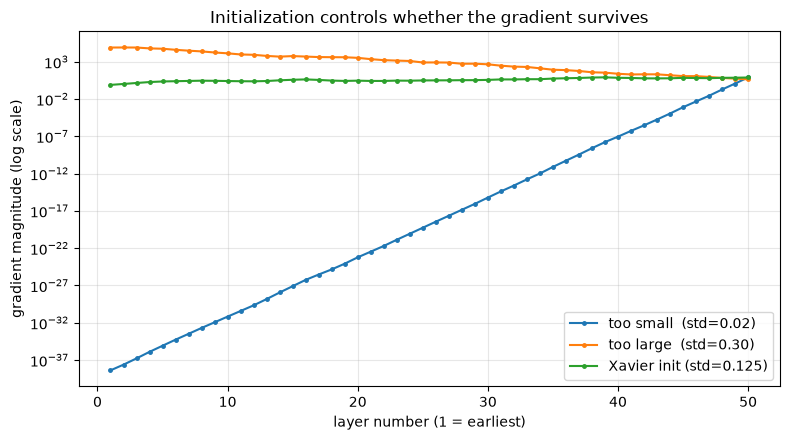

In [4]:
L, width = 50, 64
setups = {
    "too small  (std=0.02)": 0.02,
    "too large  (std=0.30)": 0.30,
    f"Xavier init (std={np.sqrt(1/width):.3f})": np.sqrt(1 / width),
}

plt.figure()
for label, std in setups.items():
    g = forward_backward(make_net(L, width=width, w_std=std))
    plt.plot(range(1, L + 1), g, marker="o", ms=2.5, label=label)

plt.yscale("log")
plt.xlabel("layer number (1 = earliest)")
plt.ylabel("gradient magnitude (log scale)")
plt.title("Initialization controls whether the gradient survives")
plt.legend()
plt.tight_layout(); plt.show()

- **too small** → gradient vanishes (dives toward the bottom).
- **too large** → gradient explodes (climbs off the top).
- **Xavier init** → stays in a healthy band across all 50 layers.

Same architecture, same depth — *only the starting weights differ*. This
(plus Batch Normalization, which keeps the signal well-scaled **during**
training too) is what let networks of "tens of layers" train by 2015.

## 4. The ResNet trick: skip connections

Good init keeps the *average* factor near 1, but it's a balancing act that gets
harder with depth. ResNet changes the **structure** so gradients have a
guaranteed escape route.

- **Plain block:**    $a = \tanh(W a_{\text{prev}})$
- **Residual block:** $a = a_{\text{prev}} + \tanh(W a_{\text{prev}})$  ← add the input back

Backprop through the residual block gives
$da_{\text{prev}} = \underbrace{da}_{\text{identity path}} + W^\top(\dots)$.
That first `da` term is a **direct wire** — the gradient can flow straight back
through the `+ a_prev` with no shrinking factor. Let's compare the two.

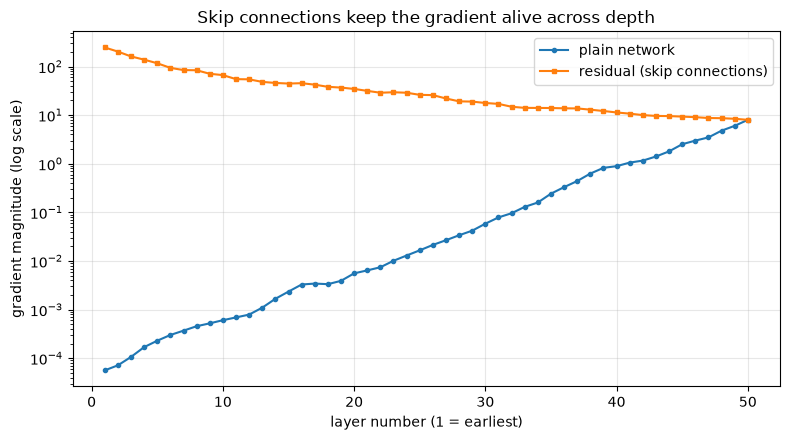

plain    — first-layer gradient: 5.630e-05
residual — first-layer gradient: 2.462e+02


In [5]:
def flow(weights, residual):
    width = weights[0].shape[0]
    a = np.random.default_rng(1).normal(0, 1, size=(width, 1))
    cache = []
    for W in weights:
        z = W @ a
        cache.append((a, z))
        a = a + np.tanh(z) if residual else np.tanh(z)
    da = np.ones_like(a)
    norms = []
    for W, (a_prev, z) in zip(reversed(weights), reversed(cache)):
        dz = da * (1 - np.tanh(z) ** 2)
        da_prev = W.T @ dz
        if residual:
            da_prev = da_prev + da          # <-- the identity shortcut
        norms.append(np.linalg.norm(da))
        da = da_prev
    return np.array(norms[::-1])

L = 50
W = make_net(L, w_std=0.1)
plain = flow(W, residual=False)
resid = flow(W, residual=True)

plt.figure()
plt.plot(range(1, L + 1), plain, marker="o", ms=3, label="plain network")
plt.plot(range(1, L + 1), resid, marker="s", ms=3, label="residual (skip connections)")
plt.yscale("log")
plt.xlabel("layer number (1 = earliest)")
plt.ylabel("gradient magnitude (log scale)")
plt.title("Skip connections keep the gradient alive across depth")
plt.legend()
plt.tight_layout(); plt.show()

print(f"plain    — first-layer gradient: {plain[0]:.3e}")
print(f"residual — first-layer gradient: {resid[0]:.3e}")

The plain network's gradient decays toward the input; the residual network's
stays roughly flat, because the `+ a_prev` shortcut hands the gradient a
lossless path straight back to every earlier layer.

### Takeaways
- A gradient is a **product of per-layer factors**; products vanish or explode.
- **Initialization + normalization** keep those factors near 1 — the fix ResNet
  says had "largely addressed" this problem.
- **Skip connections** go further: they give the gradient an identity highway,
  so depth stops hurting. That's the structural idea behind ResNet — and it's
  now in Transformers, diffusion models, and most modern deep nets.

*Try it:* raise `L` to 150, switch `tanh` to sigmoid (`1/(1+np.exp(-z))`, slope
≤ 0.25 → vanishes faster), or change `w_std` and watch the curves move.